# Credit Card Fraud Detection

## 1. Introduction

Credit card fraud is a major problem in the financial sector. With the increasing use of credit and online transactions, detecting fraudulent transactions accurately and quickly has become increasingly important.

Machine Learning can be used to analyze transaction patterns and classify transactions as either **legitimate** or **fraudulent**. The goal is to build a model that can detect suspicious transactions while minimizing false predictions.

In this project, we will explore a credit card transaction dataset, perform exploratory data analysis (EDA), preprocess the data, train several Machine Learning models, and evaluate their performance using appropriate classification metrics.

## 2. Problem Definition

The objective of this project is to build a Machine Learning classification model that can determine whether a credit card transaction is **fraudulent or legitimate**.

This is a **binary classification problem**, where:

- `0` → Legitimate transaction
- `1` → Fraudulent transaction

The main challenge is that fraudulent transactions are usually much less common than legitimate transactions, resulting in an **imbalanced dataset**. Therefore, accuracy alone may not be a suitable metric for evaluating the models.

We will focus on metrics such as:

- **Precision** — How many transactions predicted as fraud were actually fraudulent.
- **Recall** — How many actual fraudulent transactions were successfully detected.
- **F1-Score** — The harmonic mean of precision and recall.
- **Confusion Matrix** — To understand the types of classification errors.
- **ROC-AUC** — To measure the model's ability to distinguish between fraudulent and legitimate transactions.

The final goal is to develop a model that can effectively identify fraudulent transactions while maintaining a reasonable number of false positives.

## 3. Dataset

The dataset contains information about credit card transactions, with each row representing a single transaction.

The dataset includes a target variable that indicates whether the transaction is fraudulent or legitimate. The remaining columns represent the characteristics of each transaction that can be used as input features for the Machine Learning models.

### Dataset Characteristics

Before building the models, we will investigate:

- The number of rows and columns.
- The data types of the features.
- Missing values.
- Duplicate records.
- The distribution of fraudulent and legitimate transactions.
- The statistical properties of numerical features.
- Possible outliers and unusual observations.
- Relationships between the features and the target variable.

### Target Variable

The target variable is the transaction class:

| Class | Meaning |
|------:|---------|
| `0` | Legitimate transaction |
| `1` | Fraudulent transaction |

Since fraud cases are expected to represent a small portion of the transactions, we will pay particular attention to **class imbalance** during the EDA, preprocessing, model training, and evaluation stages.

In [1]:
# importing necessary librares
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
df=pd.read_csv("creditcard.csv")

In [16]:
df.shape

(284807, 31)

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.isna().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


### Observation
The dataset is not balanced

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


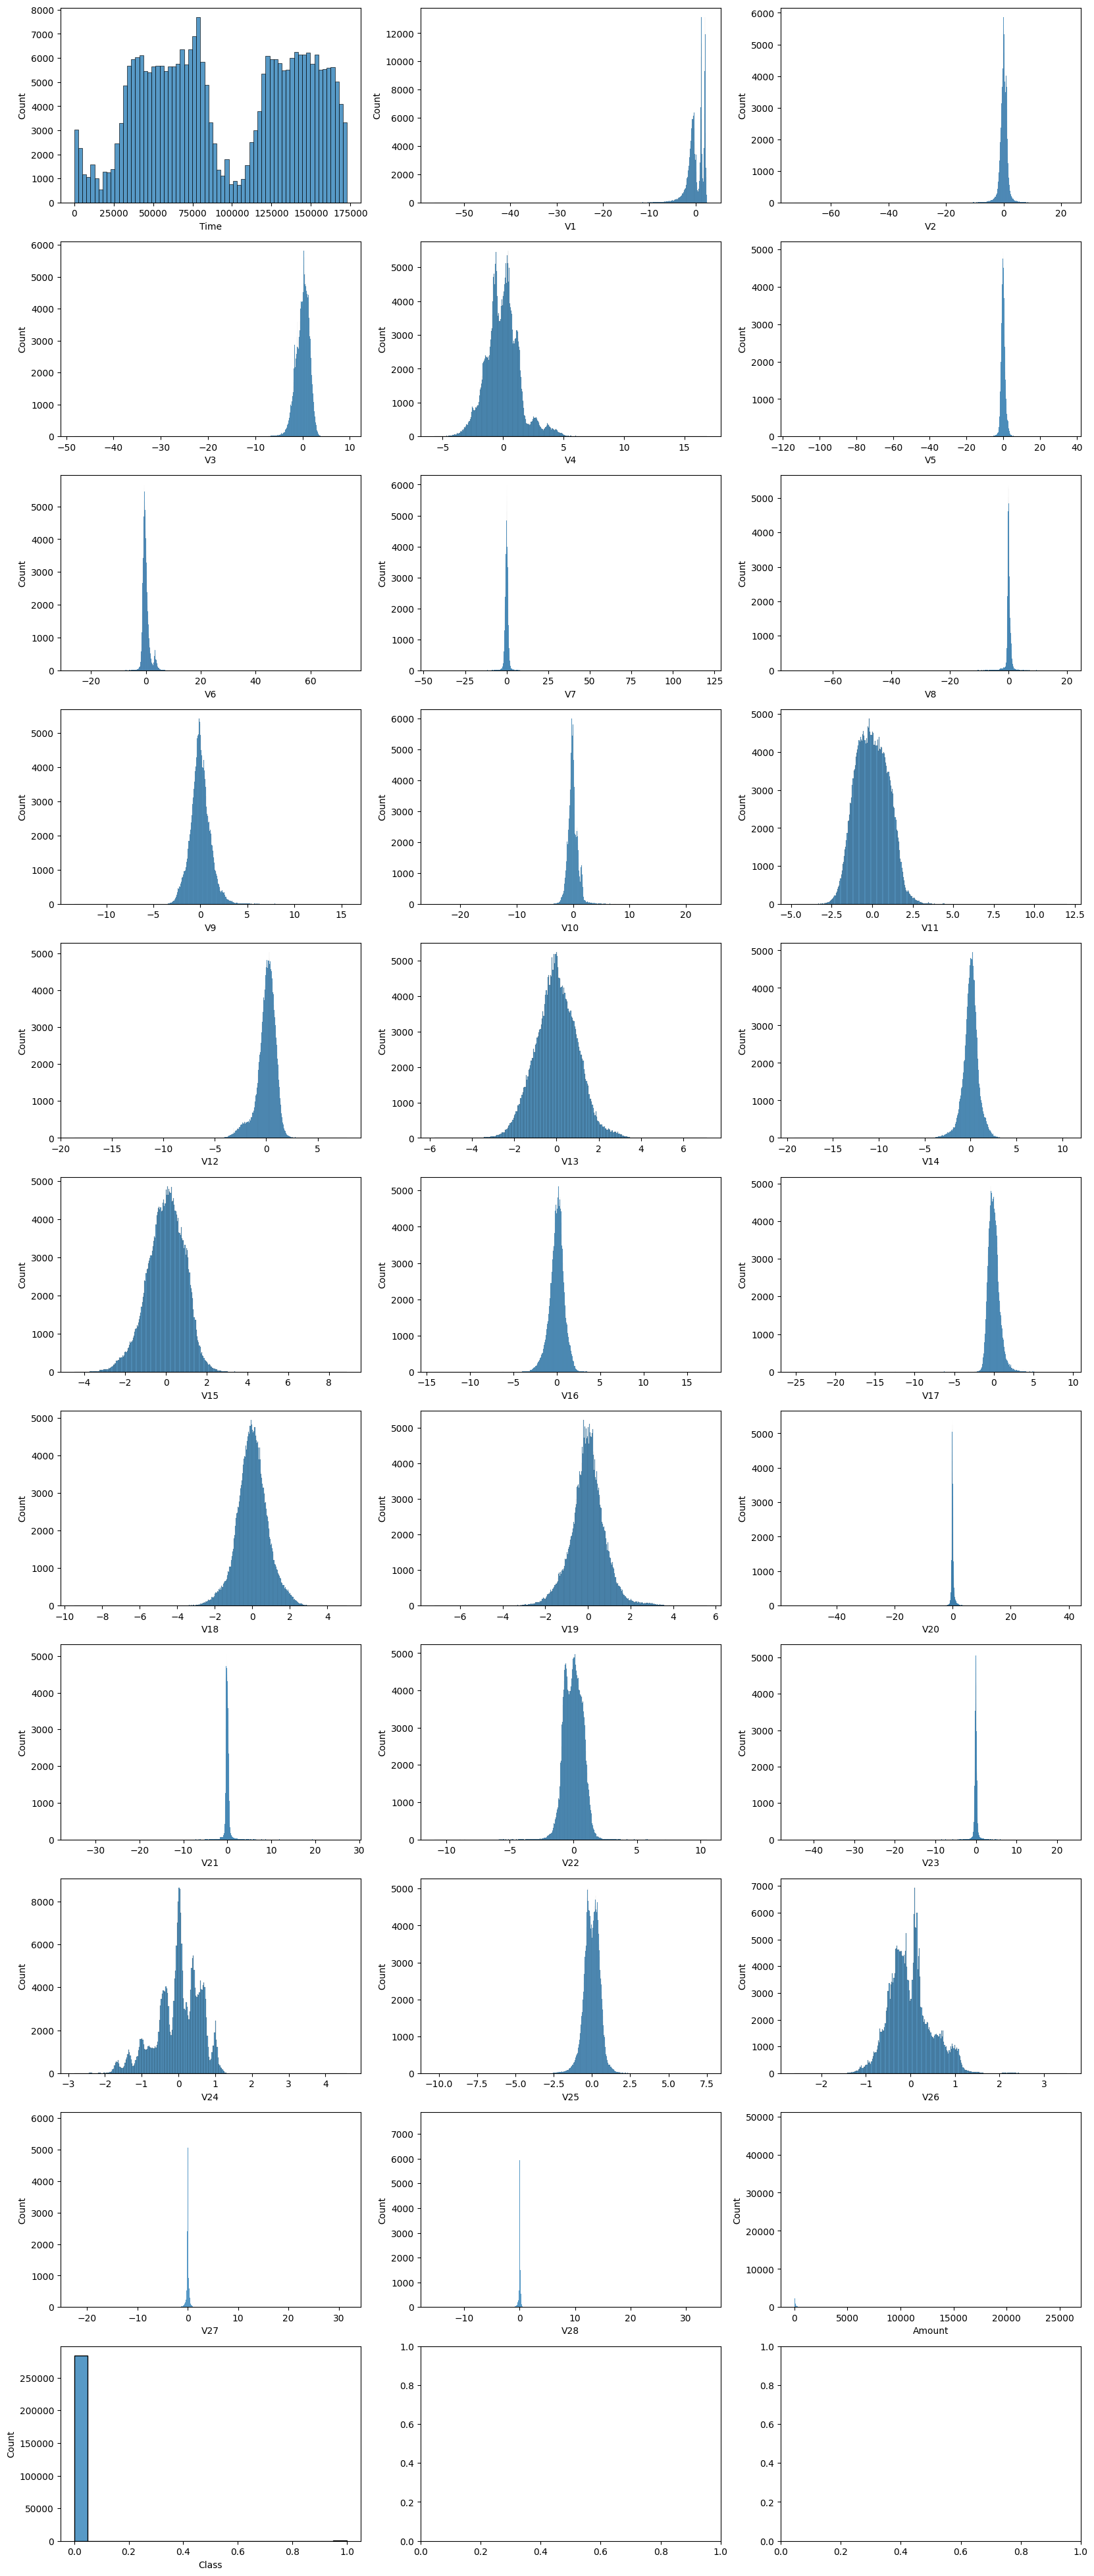

In [ ]:
fig,ax=plt.subplots(nrows=11,ncols=3,figsize=(20,50))
Features=df.loc[:,"Time":"Class"].columns
axes=ax.flatten()
for i,Feature in enumerate(Features):
    sns.histplot(data=df,x=Feature,ax=axes[i])




## Splitting Data

In [41]:
from sklearn.preprocessing import  StandardScaler
from sklearn.model_selection import train_test_split
x=df.drop("Class",axis=1)
y=df["Class"]
x_train,x_tmp,y_train,y_tmp=train_test_split(x,y,test_size=0.3,
                                             random_state=42,
                                             shuffle=True,
                                             stratify=y)
x_val,x_test,y_val,y_test=train_test_split(x_tmp,y_tmp,test_size=0.5,
                                             random_state=42,
                                             shuffle=True,
                                             stratify=y_tmp)

In [43]:
print(f"x train shape :{x_train.shape}")
print(f"y train shape :{y_train.shape}")
print(f"x val shape :{x_val.shape}")
print(f"y val shape :{y_val.shape}")
print(f"x test shape :{x_test.shape}")
print(f"y test shape :{y_test.shape}")

x train shape :(199364, 30)
y train shape :(199364,)
x val shape :(42721, 30)
y val shape :(42721,)
x test shape :(42722, 30)
y test shape :(42722,)


## Scaling Data

In [44]:
standard_scaler=StandardScaler()
x_train_transformed=standard_scaler.fit_transform(x_train)
x_val_transformed=standard_scaler.transform(x_val)
x_test_transformed=standard_scaler.transform(x_test)

## Training unsupervised ML Models


In [67]:
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor
isolation_forest=IsolationForest(random_state=42,contamination=0.01)
dbscan=DBSCAN(   eps=0.5,
    min_samples=10,
    metric="euclidean")
Local_Outlier=LocalOutlierFactor(n_neighbors=50,
    contamination=0.01, novelty=True)
Models_info=[("isolation_forest",isolation_forest),
        ("Local_Outlier",Local_Outlier)]

In [45]:
# Evaluation Models
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import ConfusionMatrixDisplay

def View_Results( dataset_name,y_true,y_preds):
  print(f"dataset :{dataset_name}")
  print(f"Accuracy Score : {accuracy_score(y_true,y_preds)}")
  print(f"F1 Score : {f1_score(y_true,y_preds)}")
  print(f"Recall Score : {recall_score(y_true,y_preds)}")
  print(f"precision Score : {precision_score(y_true,y_preds)}")
  ConfusionMatrixDisplay.from_predictions(y_true,y_preds)
  plt.show()
  print("------------------------------------------")


def Evaluate_Model(Models_info,x_train,y_train,
                   x_val=None,y_val=None
                   ,x_test=None,y_test=None):
  for Model in Models_info:

    Model_name=Model[0]
    Model=Model[1]

    Model.fit(x_train,y_train)
    y_train_predictions=np.where(Model.predict(x_train)==-1,1,0)
    print(f"{Model_name}")
    View_Results( "Traning Dataset",y_train,y_train_predictions)
    if x_val is not None:
      y_val_predictions=np.where(Model.predict(x_val)==-1,1,0)
      View_Results( "Valdation Dataset",y_val,y_val_predictions)
    if x_test is not None:
      y_test_predictions=np.where(Model.predict(x_test)==-1,1,0)
      View_Results( "Test Dataset",y_test,y_test_predictions)









isolation_forest
dataset :Traning Dataset
Accuracy Score : 0.9904857142857143
F1 Score : 0.18181818181818182
Recall Score : 0.6491228070175439
precision Score : 0.10571428571428572
------------------------------------------
Local_Outlier
dataset :Traning Dataset
Accuracy Score : 0.9907142857142858
F1 Score : 0.13333333333333333
Recall Score : 0.43859649122807015
precision Score : 0.07861635220125786
------------------------------------------


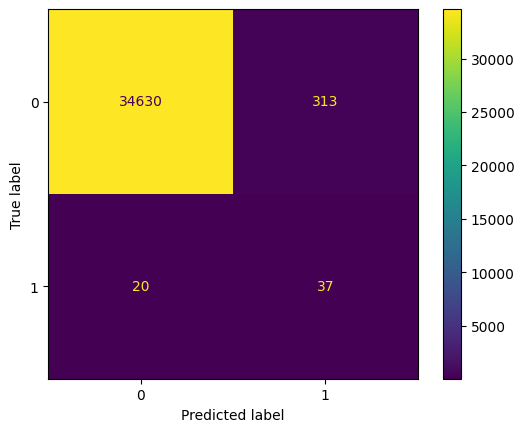

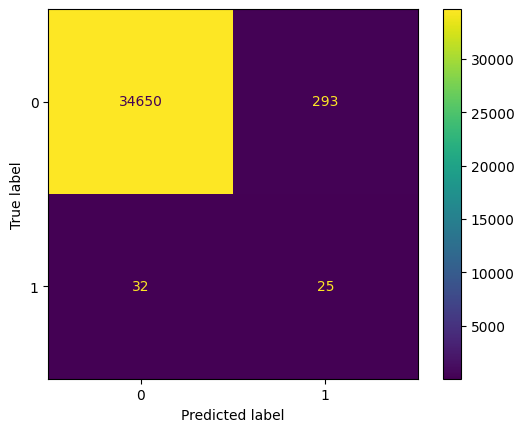

In [ ]:
Evaluate_Model(Models_info,x_train_transformed,y_train,
                   x_val=None,y_val=None
                   ,x_test=None,y_test=None)

In [ ]:
dbscan.fit(x_train)

y_train_predictions = np.where(
    dbscan.labels_ == -1, 1, 0
)


Dbscan
dataset :Training set
Accuracy Score : 0.0016285714285714287
F1 Score : 0.0032518469920415323
Recall Score : 1.0
precision Score : 0.0016285714285714287
------------------------------------------


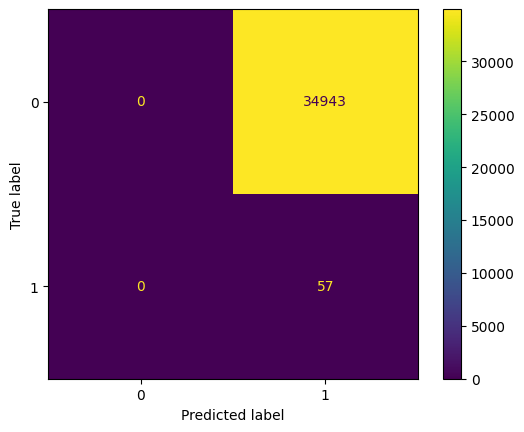

In [ ]:
print("Dbscan")
View_Results("Training set",y_train,y_train_predictions)

## hyper paramter tunning

In [46]:
from sklearn.model_selection import RandomizedSearchCV
def Do_RandomizedSearchCV(model,params,x_train,y_train,n_iter):
  model_RandomizedSearchCV=RandomizedSearchCV(model,params,cv=3,n_jobs=-1,scoring="recall",n_iter=n_iter)
  model_RandomizedSearchCV.fit(x_train,y_train)
  return ("best model params",model_RandomizedSearchCV.best_params_)



In [47]:
from sklearn.model_selection import GridSearchCV
def Do_GridSearchCV(model,params,x_train,y_train):
  model_GridSearchCV=GridSearchCV(model,params,cv=3,n_jobs=-1,scoring="recall")
  model_GridSearchCV.fit(x_train,y_train)
  return ("best model params",model_GridSearchCV.best_params_)






In [94]:
param_grid = {
    "n_estimators": [30,50,70,100,125,150],

    "max_samples": [  0.7,0.8,0.9, 1.0],

    "max_features": [ 0.7, 0.8,0.9, 1.0],

    "contamination": [ 0.005],

    "bootstrap": [ True]
}
Do_GridSearchCV(IsolationForest(random_state=42)
                    ,param_grid
                      ,x_train_transformed
                      ,y_train

                      )

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan]
  warnings.warn(


('best model params',
 {'bootstrap': True,
  'contamination': 0.005,
  'max_features': 0.7,
  'max_samples': 0.7,
  'n_estimators': 30})

isolation_forest
dataset :Traning Dataset
Accuracy Score : 0.995269958467928
F1 Score : 0.29679343773303507
Recall Score : 0.5784883720930233
precision Score : 0.1995987963891675


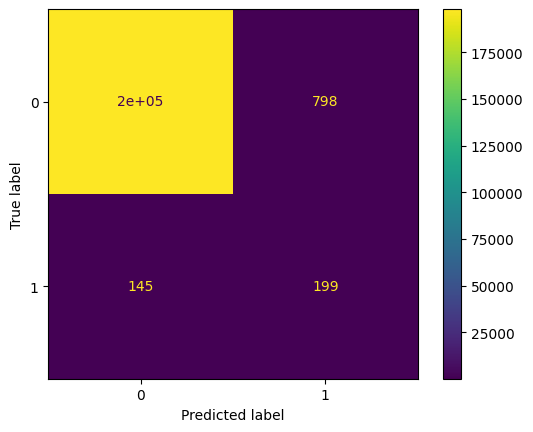

------------------------------------------
dataset :Valdation Dataset
Accuracy Score : 0.9950375693452869
F1 Score : 0.2980132450331126
Recall Score : 0.6081081081081081
precision Score : 0.19736842105263158


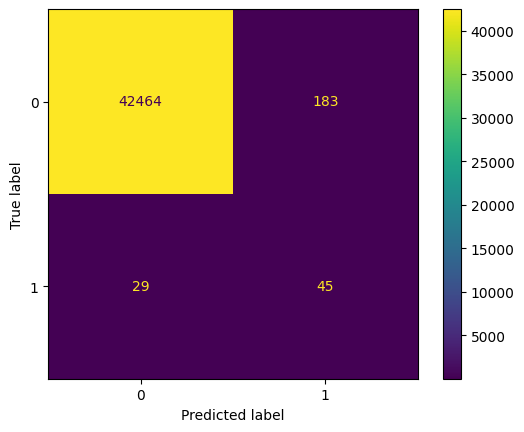

------------------------------------------
dataset :Test Dataset
Accuracy Score : 0.995341978371799
F1 Score : 0.27636363636363637
Recall Score : 0.5135135135135135
precision Score : 0.1890547263681592


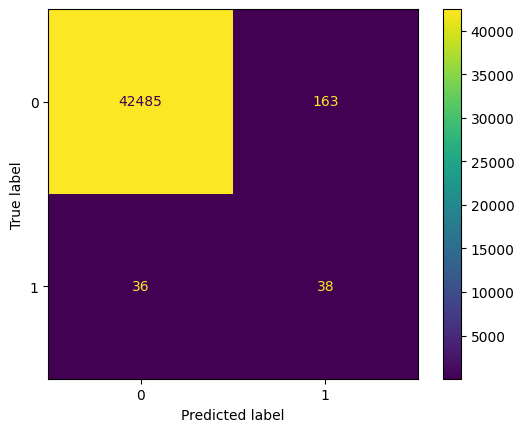

------------------------------------------


In [99]:
isolation_forest=IsolationForest(random_state=42,n_estimators= 30,
  max_samples= 0.7,
  max_features= 0.7,
  contamination= 0.005,
  bootstrap= True)
Evaluate_Model([("isolation_forest",isolation_forest)],x_train_transformed,y_train,
                   x_val=x_val_transformed,y_val=y_val
                   ,x_test=x_test_transformed,y_test=y_test)



### observation
 The Isolataion Forest is the best unsupervised alogorthim  by far

## Training Supervised ML Models

In [48]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train_resampled,y_train_resampled=smote.fit_resample(x_train_transformed,y_train)

In [49]:
y_train_resampled.value_counts()

,count
Class,
0,199020
1,199020


In [50]:
x_train_resampled.shape

(398040, 30)

In [51]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC

linear_svc=LinearSVC()
log_reg = LogisticRegression(
    random_state=42
)
XGB=XGBClassifier(random_state=42)

Models_info=[
    ("log_reg",log_reg),
    ("XGBClassifier",XGB),
    ("linear_svc",linear_svc)
]


In [52]:
def Evaluate_UnSupervised_Model(Models_info,x_train,y_train,
                   x_val=None,y_val=None
                   ,x_test=None,y_test=None):
  for Model in Models_info:

    Model_name=Model[0]
    Model=Model[1]

    Model.fit(x_train,y_train)
    y_train_predictions=Model.predict(x_train)
    print(f"{Model_name}")
    View_Results( "Traning Dataset",y_train,y_train_predictions)
    if x_val is not None:
      y_val_predictions=Model.predict(x_val)
      View_Results( "Valdation Dataset",y_val,y_val_predictions)
    if x_test is not None:
      y_test_predictions=Model.predict(x_test)
      View_Results( "Test Dataset",y_test,y_test_predictions)


log_reg
dataset :Traning Dataset
Accuracy Score : 0.9589614109134761
F1 Score : 0.958166550142518
Recall Score : 0.9399608079589991
precision Score : 0.9770914617903759


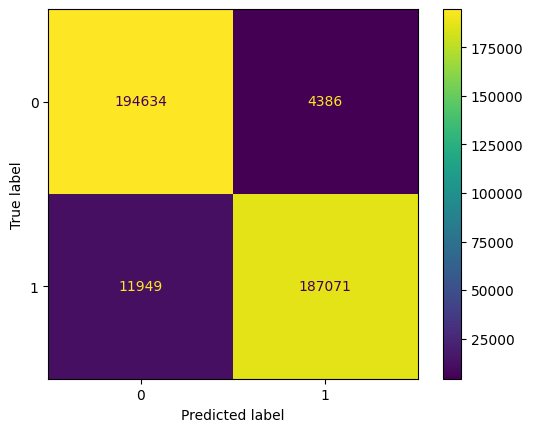

------------------------------------------
dataset :Valdation Dataset
Accuracy Score : 0.9780435851220711
F1 Score : 0.12172284644194757
Recall Score : 0.8783783783783784
precision Score : 0.06539235412474849


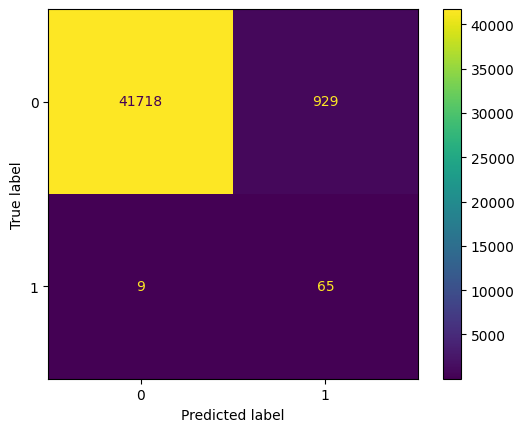

------------------------------------------
XGBClassifier
dataset :Traning Dataset
Accuracy Score : 1.0
F1 Score : 1.0
Recall Score : 1.0
precision Score : 1.0


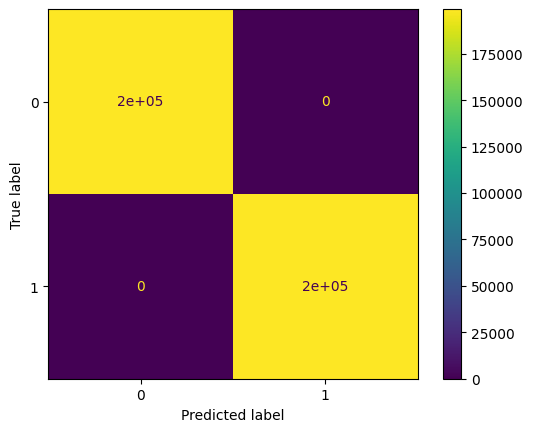

------------------------------------------
dataset :Valdation Dataset
Accuracy Score : 0.9993445846305096
F1 Score : 0.8082191780821918
Recall Score : 0.7972972972972973
precision Score : 0.8194444444444444


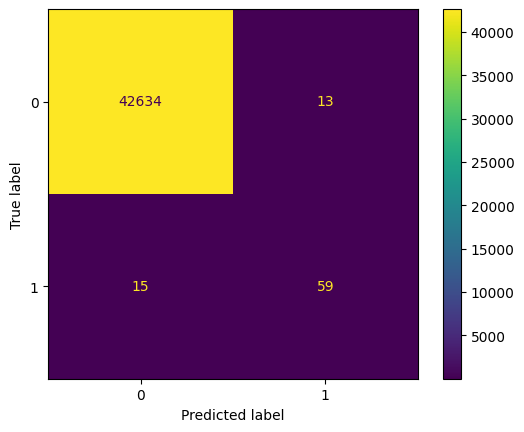

------------------------------------------
linear_svc
dataset :Traning Dataset
Accuracy Score : 0.9549894482966536
F1 Score : 0.9537844823583431
Recall Score : 0.9289166917897699
precision Score : 0.980020356018278


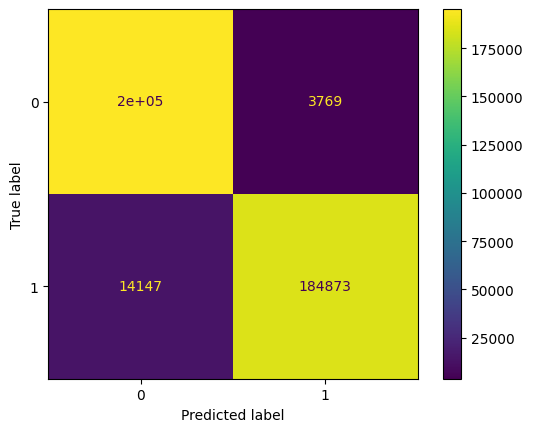

------------------------------------------
dataset :Valdation Dataset
Accuracy Score : 0.9803843542988226
F1 Score : 0.13429752066115702
Recall Score : 0.8783783783783784
precision Score : 0.07270693512304251


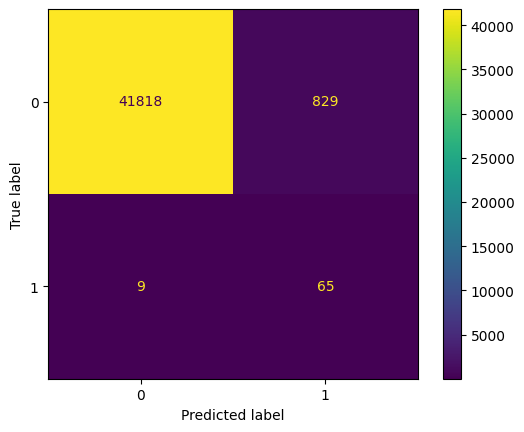

------------------------------------------


In [53]:
Evaluate_UnSupervised_Model(Models_info,x_train_resampled,y_train_resampled,
                   x_val=x_val_transformed,y_val=y_val
                   ,x_test=None,y_test=None)

In [69]:
log_reg_param_grid = {
    "C": [0.1,1,10,50 ,100,125,150,175,200],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": [None]
}
Do_GridSearchCV(LogisticRegression(random_state=42),log_reg_param_grid,x_train_resampled,y_train_resampled)



('best model params',
 {'C': 175, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'})

In [70]:
log_reg=LogisticRegression(random_state=42,
                           C=175,
                    penalty="l2",
                    solver="liblinear",
                    class_weight=None)



In [117]:
XGB_param_distributions = {
         "n_estimators": [100, 200, 300, 500, 800]
         ,     "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2]
         ,     "max_depth": [3, 4, 5, 6, 8]
         ,     "min_child_weight": [1, 3, 5, 10]
         ,     "subsample": [0.6, 0.8, 1.0]
         ,     "colsample_bytree": [0.6, 0.8, 1.0]
         ,     "gamma": [0, 0.1, 0.5, 1] }



Do_RandomizedSearchCV(XGBClassifier(random_state=42)
                    ,XGB_param_distributions
                      ,x_train_resampled
                      ,y_train_resampled
                      ,50
                      )

('best model params',
 {'subsample': 0.7,
  'n_estimators': 300,
  'min_child_weight': 10,
  'max_depth': 5,
  'learning_rate': 0.1,
  'gamma': 0.5,
  'colsample_bytree': 0.6})

In [123]:
XGB_clf =XGBClassifier(random_state=42,
    subsample= 1.0,
  n_estimators= 500,
  min_child_weight= 1,
  max_depth= 6,
  learning_rate= 0.2,
  gamma= 0.1,
  colsample_bytree= 0.6
)

In [58]:
params = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "class_weight": [None],
    "tol": [0.1,0.01,0.001,1e-3, 1e-4],
    "max_iter": [1000, 5000,10000]
}
Do_GridSearchCV(LinearSVC()
                    ,params
                      ,x_train_resampled
                      ,y_train_resampled

                      )

('best model params',
 {'C': 0.01, 'class_weight': None, 'max_iter': 1000, 'tol': 0.1})

In [59]:
linear_svc=LinearSVC(tol= 0.1, max_iter= 1000, class_weight= None, C= 0.01)


In [124]:
Models_info=[
    ("log_reg",log_reg),
   ("XGB_clf",XGB_clf),
   ("linear_svc",linear_svc),
]


log_reg
dataset :Traning Dataset
Accuracy Score : 0.9591046126017486
F1 Score : 0.9583220249586497
Recall Score : 0.9403276052658024
precision Score : 0.9770185751725434


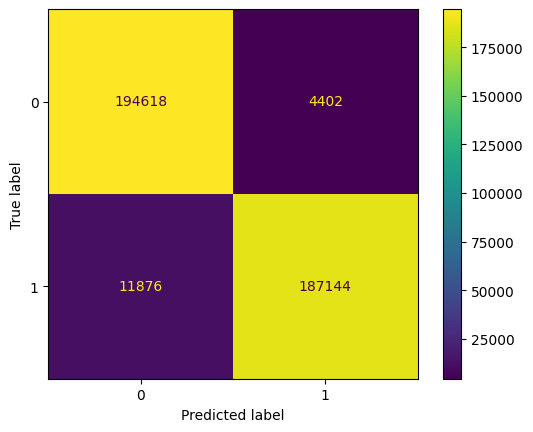

------------------------------------------
dataset :Valdation Dataset
Accuracy Score : 0.9777861005126285
F1 Score : 0.12048192771084337
Recall Score : 0.8783783783783784
precision Score : 0.06467661691542288


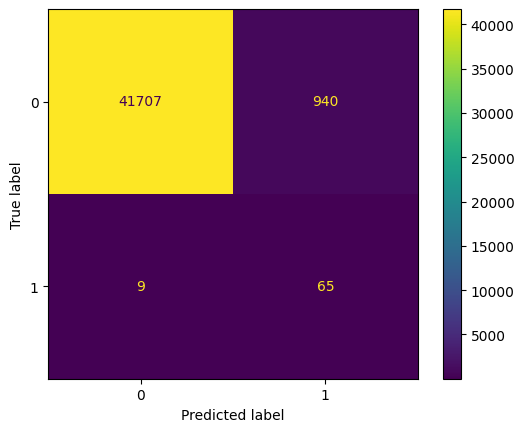

------------------------------------------
XGB_clf
dataset :Traning Dataset
Accuracy Score : 1.0
F1 Score : 1.0
Recall Score : 1.0
precision Score : 1.0


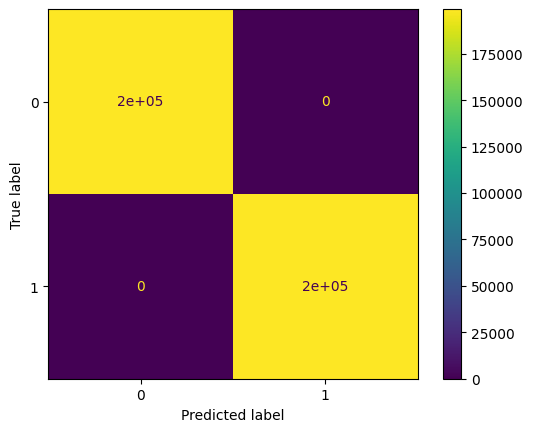

------------------------------------------
dataset :Valdation Dataset
Accuracy Score : 0.9994382153975796
F1 Score : 0.8333333333333334
Recall Score : 0.8108108108108109
precision Score : 0.8571428571428571


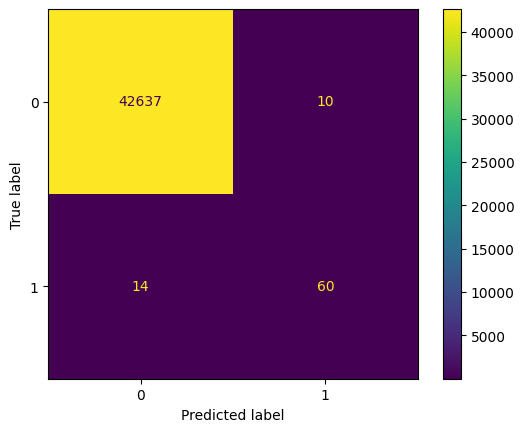

------------------------------------------
linear_svc
dataset :Traning Dataset
Accuracy Score : 0.9475153250929554
F1 Score : 0.9478885781920772
Recall Score : 0.9546779218169028
precision Score : 0.9411951196556216


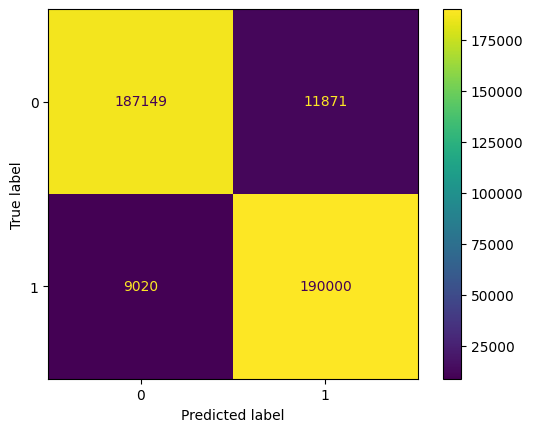

------------------------------------------
dataset :Valdation Dataset
Accuracy Score : 0.9387888860279487
F1 Score : 0.04805242082271569
Recall Score : 0.8918918918918919
precision Score : 0.024691358024691357


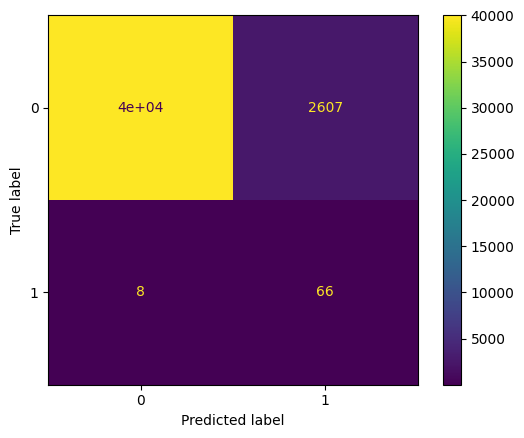

------------------------------------------


In [125]:
Evaluate_UnSupervised_Model(Models_info,x_train_resampled,y_train_resampled,
                   x_val=x_val_transformed,y_val=y_val
                   )

In [126]:
## adjusting the the threesold for xgbboost
XGB_clf.fit(x_train_resampled,y_train_resampled)
y_prob = XGB_clf.predict_proba(x_val_transformed)[:, 1]
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1:        {f1:.4f}")
    print("-" * 30)

Threshold: 0.1
Precision: 0.6238
Recall:    0.8514
F1:        0.7200
------------------------------
Threshold: 0.2
Precision: 0.6813
Recall:    0.8378
F1:        0.7515
------------------------------
Threshold: 0.3
Precision: 0.7470
Recall:    0.8378
F1:        0.7898
------------------------------
Threshold: 0.4
Precision: 0.8267
Recall:    0.8378
F1:        0.8322
------------------------------
Threshold: 0.5
Precision: 0.8571
Recall:    0.8108
F1:        0.8333
------------------------------



## Observation: Supervised Models


After applying oversampling to address the class imbalance, the performance of the supervised models improved significantly in detecting fraudulent transactions. However, the models showed different trade-offs between recall and precision.

- **Logistic Regression** achieved a high recall of **87.84%** on the validation , meaning it was able to detect most fraudulent transactions. However, its precision was very low (**6.47%** on validation ), resulting in a low F1-score. This indicates that the model produced a large number of false positives.

- **Linear SVC** showed a similar behavior, achieving high recall (**89.19%** on validation ) but extremely low precision (**2.47%** on validation ). Therefore, it generated too many false fraud predictions and was not suitable for this problem.

- **XGBoost** achieved the best overall performance. It obtained a valdation recall of **81.08%**, precision of **85.33%**, and F1-score of **83.19%**. Although its recall was slightly lower than Logistic Regression and Linear SVC, it provided a much better balance between detecting fraudulent transactions and minimizing false positives.

Overall, **XGBoost was selected as the best supervised model** because it achieved a strong balance between recall and precision. Since detecting fraudulent transactions is the main objective, the classification threshold was further adjusted to **0.4**, increasing the recall on the validation set to **83.78%** while maintaining a high precision of **82.67%**.
```


In [129]:
# concating traning and valdation set to fit the model on both of them
x_train_final = np.concat([x_train_resampled
                         , x_val_transformed]
                        , axis=0)
y_train_final = np.concat([y_train_resampled
                         , y_val]
                        , axis=0)

Precision: 0.8309859154929577
Recall: 0.7972972972972973
F1: 0.8137931034482758


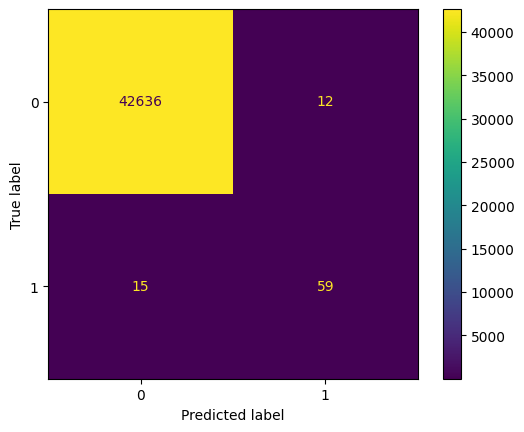

In [130]:
XGB_clf.fit(x_train_final,y_train_final)
y_test_prob = XGB_clf.predict_proba(x_test_transformed)[:, 1]

y_test_pred = (y_test_prob >= 0.4).astype(int)

print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1:", f1_score(y_test, y_test_pred))
ConfusionMatrixDisplay.from_predictions(y_test,y_test_pred)